
<div style="background:linear-gradient(135deg,#0F172A 0%,#1E3A5F 100%);
            padding:40px 36px 32px;border-radius:14px;
            border-left:6px solid #2563EB;margin-bottom:4px">

  <div style="font-size:10px;color:#60A5FA;letter-spacing:3px;
              font-family:monospace;text-transform:uppercase;margin-bottom:12px">
    ● 7CS525 · Component 5 — Automation Artefact · University of Derby 2025/26
  </div>

  <h1 style="font-size:32px;font-weight:800;color:#F0F4FF;margin:0 0 6px;
             font-family:'Segoe UI',sans-serif;letter-spacing:-0.5px">
    AI Fraud Detection — Law-Risk-Governance<br>Relational Mapper</h1>

  <p style="font-size:14px;color:#94A3B8;font-family:monospace;margin:12px 0 20px">
    EU AI Act · UK GDPR · Equality Act 2010 · FCA Rules · ECHR Art.13</p>

  <div style="display:flex;flex-wrap:wrap;gap:8px;margin-bottom:16px">
    <span style="background:rgba(239,68,68,0.18);border:1px solid rgba(239,68,68,0.5);
                 color:#FCA5A5;padding:3px 12px;border-radius:20px;font-family:monospace;
                 font-size:11px;font-weight:700">🔴 HIGH RISK — Annex III §5(b)</span>
    <span style="background:rgba(37,99,235,0.18);border:1px solid rgba(37,99,235,0.5);
                 color:#93C5FD;padding:3px 12px;border-radius:20px;
                 font-family:monospace;font-size:11px">50,000 transactions/day</span>
    <span style="background:rgba(6,182,212,0.18);border:1px solid rgba(6,182,212,0.5);
                 color:#67E8F9;padding:3px 12px;border-radius:20px;
                 font-family:monospace;font-size:11px">6 analytical modules</span>
    <span style="background:rgba(34,197,94,0.18);border:1px solid rgba(34,197,94,0.5);
                 color:#86EFAC;padding:3px 12px;border-radius:20px;
                 font-family:monospace;font-size:11px">Google Colab: Runtime → Run All</span>
  </div>

  <hr style="border:none;border-top:1px solid rgba(255,255,255,0.1);margin:16px 0"/>

  <table style="font-family:monospace;font-size:11px;color:#94A3B8;
                border-collapse:collapse;width:100%">
    <tr>
      <td style="padding:3px 20px 3px 0;color:#60A5FA;font-weight:700">Module A</td>
      <td style="padding:3px 0">Law → Risk Relational Graph (networkx + pyvis)</td>
      <td style="padding:3px 20px 3px 30px;color:#60A5FA;font-weight:700">Module D</td>
      <td>Oversight Impossibility — Mathematical Proof</td>
    </tr>
    <tr>
      <td style="padding:3px 20px 3px 0;color:#60A5FA;font-weight:700">Module B</td>
      <td>Compliance Gap Heatmap (article × obligation)</td>
      <td style="padding:3px 20px 3px 30px;color:#60A5FA;font-weight:700">Module E</td>
      <td>Enforcement Cases Timeline</td>
    </tr>
    <tr>
      <td style="padding:3px 20px 3px 0;color:#60A5FA;font-weight:700">Module C</td>
      <td>Risk Register — L×I Matrix with law traceability</td>
      <td style="padding:3px 20px 3px 30px;color:#60A5FA;font-weight:700">Module F</td>
      <td>Governance Action → Law → Risk Dashboard</td>
    </tr>
  </table>
</div>

> **How to use this notebook:**  
> In Google Colab click **Runtime → Run All**. Every cell is independently documented.  
> Hover over graph nodes and chart elements for full legal detail.  
> All data is in **Cell 1 (System Data)**. Change any value there to re-run the full analysis.


In [6]:
import subprocess, sys

def _install(p):
    subprocess.check_call([sys.executable, "-m", "pip", "install", p, "-q"])

for _p in ["pyvis", "plotly", "pandas", "networkx", "matplotlib", "seaborn"]:
    try:
        __import__(_p)
    except ImportError:
        _install(_p)

import warnings; warnings.filterwarnings("ignore")
import networkx as nx
import pandas as pd
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from pyvis.network import Network
from IPython.display import display, HTML
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import matplotlib.colors as mcolors
import numpy as np
from datetime import datetime

# ── COLOUR PALETTE (consistent across all modules) ──────────────────────────
PALETTE = {
    "navy":   "#1E293B",   # background / axis
    "blue":   "#2563EB",   # primary accent
    "sky":    "#38BDF8",   # secondary blue
    "cyan":   "#06B6D4",   # highlight
    "red":    "#EF4444",   # GAP / Critical
    "orange": "#F97316",   # High risk
    "amber":  "#F59E0B",   # Medium / Partial
    "green":  "#22C55E",   # MET / Low
    "purple": "#8B5CF6",   # provider duties
    "white":  "#F0F4FF",
    "muted":  "#64748B",
    "bg":     "#050B14",
}

# ── SYSTEM PROFILE ───────────────────────────────────────────────────────────
#  Edit this to change the system under analysis
SYSTEM = {
    "name":              "AI-Driven Transaction Fraud Detection System",
    "sector":            "UK Retail Banking",
    "tech":              "Gradient Boosting + Neural Network ensemble",
    "daily_txn":         50_000,
    "fpr":               0.025,    # False Positive Rate — 2.5%
    "analyst_capacity":  500,      # analyst reviews possible per day
    "eu_class":          "HIGH RISK",
    "annex":             "Annex III §5(b)",
    "deadline":          "August 2026",
}

FPD = int(SYSTEM["daily_txn"] * SYSTEM["fpr"])          # wrongful blocks/day
UNREVIEWED = max(0, FPD - SYSTEM["analyst_capacity"])    # blocks with no review
PCT_UNREV  = round(UNREVIEWED / FPD * 100) if FPD else 0

# ── LAW NODES ────────────────────────────────────────────────────────────────
#  Each law is a node in the relational graph.
#  article_id → label, what it requires, type, colour group

LAWS = {
    # EU AI Act — Classification
    "ANN3_5b": {
        "label": "Annex III\n§5(b)",
        "full":  "EU AI Act Annex III §5(b)",
        "what":  "Designates as HIGH RISK: AI systems making or influencing decisions "
                 "on eligibility for essential private services including banking.",
        "type":  "trigger",
        "color": PALETTE["red"],
    },
    # EU AI Act — Mandatory Obligations
    "A9":  {"label":"Art. 9\nRisk Mgmt",  "full":"EU AI Act Art.9",
            "what":"Continuous documented risk management throughout the AI lifecycle.",
            "type":"primary","color":PALETTE["blue"]},
    "A10": {"label":"Art.10\nData Gov.",   "full":"EU AI Act Art.10",
            "what":"Training data must be bias-examined, representative and complete.",
            "type":"primary","color":PALETTE["blue"]},
    "A11": {"label":"Art.11\nTech Docs",   "full":"EU AI Act Art.11",
            "what":"Full technical documentation drawn up before deployment and maintained.",
            "type":"primary","color":PALETTE["blue"]},
    "A12": {"label":"Art.12\nLogging",     "full":"EU AI Act Art.12",
            "what":"Automatic logging of decisions throughout the system's lifetime.",
            "type":"primary","color":PALETTE["blue"]},
    "A13": {"label":"Art.13\nTransparency","full":"EU AI Act Art.13",
            "what":"Deployers and affected persons receive meaningful explanation of outputs.",
            "type":"primary","color":PALETTE["sky"]},
    "A14": {"label":"Art.14\nOversight",   "full":"EU AI Act Art.14",
            "what":"High-risk AI must be effectively overseen by natural persons — "
                   "operators must understand, intervene and interrupt the system.",
            "type":"primary","color":PALETTE["sky"]},
    "A15": {"label":"Art.15\nRobustness",  "full":"EU AI Act Art.15",
            "what":"System must be resilient against errors, drift and adversarial attacks.",
            "type":"primary","color":PALETTE["blue"]},
    "A16": {"label":"Art.16\nProvider",    "full":"EU AI Act Art.16",
            "what":"ML vendor must ensure Arts.9–15 compliance before deployment.",
            "type":"primary","color":PALETTE["purple"]},
    "A17": {"label":"Art.17\nQMS",         "full":"EU AI Act Art.17",
            "what":"Formal Quality Management System covering the entire AI lifecycle.",
            "type":"primary","color":PALETTE["blue"]},
    # Accountability
    "A26": {"label":"Art.26\nDeployer",    "full":"EU AI Act Art.26",
            "what":"Bank must ensure oversight, monitor operation and inform affected persons.",
            "type":"accountability","color":PALETTE["orange"]},
    "A99": {"label":"Art.99\nPenalties",   "full":"EU AI Act Art.99",
            "what":"Non-compliance with Arts.9–17: up to €15M or 3% of global annual turnover.",
            "type":"penalty","color":PALETTE["red"]},
    # UK GDPR
    "G22": {"label":"UK GDPR\nArt.22",    "full":"UK GDPR Art.22",
            "what":"Right not to be subject to solely automated significant decisions. "
                   "Art.22(3): right to human intervention, to express view, and to contest.",
            "type":"parallel","color":PALETTE["amber"]},
    "G13": {"label":"UK GDPR\nArts.13-14","full":"UK GDPR Arts.13–14",
            "what":"Meaningful information about the logic of automated decision-making must "
                   "be provided — not just a notice that 'an algorithm was used'.",
            "type":"parallel","color":PALETTE["amber"]},
    # UK Equality Act
    "EQ19":{"label":"Eq.Act\ns.19",       "full":"Equality Act 2010 s.19",
            "what":"Indirect discrimination: applying a provision that puts a protected group "
                   "at a disadvantage without proportionate justification — intent irrelevant.",
            "type":"parallel","color":PALETTE["green"]},
    # FCA
    "FCD": {"label":"FCA\nConsumer Duty", "full":"FCA Consumer Duty (PS22/9)",
            "what":"Firms must deliver good outcomes for retail customers across four areas: "
                   "products, price, understanding, and support.",
            "type":"parallel","color":PALETTE["cyan"]},
    "FG21":{"label":"FCA\nFG21/1",        "full":"FCA FG21/1",
            "what":"Vulnerable customers must receive equally fair outcomes. Blocked payments "
                   "causing distress to elderly or cognitively impaired customers trigger this.",
            "type":"parallel","color":PALETTE["cyan"]},
    # ECHR
    "ECHR":{"label":"ECHR\nArt.13",       "full":"ECHR Art.13",
            "what":"Right to an effective remedy before a national authority. "
                   "Opacity in automated systems can itself be the violation (SyRI, 2020).",
            "type":"parallel","color":PALETTE["orange"]},
}

# ── COMPLIANCE STATUS per law (for this specific system) ────────────────────
COMPLIANCE = {
    "ANN3_5b":"TRIGGER",
    "A9":"GAP","A10":"GAP","A11":"GAP","A12":"PARTIAL",
    "A13":"GAP","A14":"GAP","A15":"GAP","A16":"GAP","A17":"GAP",
    "A26":"GAP",
    "A99":"EXPOSED",
    "G22":"GAP","G13":"GAP","EQ19":"GAP",
    "FCD":"PARTIAL","FG21":"GAP","ECHR":"GAP",
}
STATUS_COL = {
    "TRIGGER":"#2563EB","GAP":"#EF4444","PARTIAL":"#F59E0B",
    "MET":"#22C55E","EXPOSED":"#DC2626",
}

# ── RISK REGISTER ─────────────────────────────────────────────────────────────
#  10 risks — each linked to specific laws (for the relational graph)
RISKS = pd.DataFrame([
    {"ID":"R-01","Stakeholder":"Bank Customers",
     "Risk":"False positive — legitimate transaction blocked",
     "L":4,"I":4,
     "L_why":f"2.5% FPR × {SYSTEM['daily_txn']:,} txns = {FPD:,} wrongful blocks — structural, not edge case",
     "I_why":"Consumer Duty breach + Art.22 UK GDPR right denied + individual financial harm",
     "Laws":["A14","G22","FCD"],"Severity":"Critical"},
    {"ID":"R-02","Stakeholder":"Bank Customers",
     "Risk":"Discriminatory scoring via proxy variables",
     "L":3,"I":5,
     "L_why":"Proxy variables active but no audit conducted — monitoring required",
     "I_why":"Systemic Equality Act s.19 violation — class action + regulator enforcement",
     "Laws":["A10","EQ19","FCD"],"Severity":"High"},
    {"ID":"R-03","Stakeholder":"Bank Customers",
     "Risk":"No meaningful explanation for blocked payment",
     "L":5,"I":3,
     "L_why":"Every automated block creates an unmet transparency obligation — certain",
     "I_why":"ICO enforcement notice precedent (cf. Experian 2020)",
     "Laws":["A13","G22","G13"],"Severity":"High"},
    {"ID":"R-04","Stakeholder":"Fraud Analysts",
     "Risk":"Automation bias — over-reliance on AI score",
     "L":4,"I":4,
     "L_why":"Inherent in high-volume time-pressured workflow — structural, proven by 5 studies",
     "I_why":"Nullifies Art.14 compliance — oversight exists in form only",
     "Laws":["A14","A13"],"Severity":"Critical"},
    {"ID":"R-05","Stakeholder":"Fraud Analysts",
     "Risk":"Alert fatigue degrading decision quality",
     "L":4,"I":3,
     "L_why":f"{FPD:,} daily flags vs {SYSTEM['analyst_capacity']:,} capacity — threshold exceeded",
     "I_why":"Art.14(4)(e) already violated; FG21/1 vulnerable customer harm",
     "Laws":["A14","FG21"],"Severity":"High"},
    {"ID":"R-06","Stakeholder":"The Bank",
     "Risk":"Model drift causing silent performance degradation",
     "L":3,"I":4,
     "L_why":"Fraud patterns evolve — drift inevitable without active monitoring",
     "I_why":"Undetected fraud increase + FCA model risk non-compliance",
     "Laws":["A9","A15"],"Severity":"High"},
    {"ID":"R-07","Stakeholder":"The Bank",
     "Risk":"Regulatory non-compliance (FCA, ICO, EU AI Act)",
     "L":3,"I":5,
     "L_why":"Multiple gaps identified — non-compliance is the current operational state",
     "I_why":"Up to €15M / 3% global turnover + multi-regulator enforcement",
     "Laws":["A99","G22","FCD"],"Severity":"High"},
    {"ID":"R-08","Stakeholder":"ML Vendor",
     "Risk":"Opaque model — Deployer Trap (Art.16 v3)",
     "L":4,"I":4,
     "L_why":"Standard black-box-as-a-service — structural feature of current contract",
     "I_why":"Bank bears Art.26 liability it cannot discharge; Art.16 unverified",
     "Laws":["A16","A26","A11"],"Severity":"Critical"},
    {"ID":"R-09","Stakeholder":"The Bank",
     "Risk":"Data poisoning / adversarial attack on pipeline",
     "L":2,"I":5,
     "L_why":"Requires targeted threat actor — possible under adverse conditions",
     "I_why":"Complete model integrity compromise — all decisions corrupted",
     "Laws":["A9","A15"],"Severity":"Medium"},
    {"ID":"R-10","Stakeholder":"Regulators",
     "Risk":"Systemic discrimination at scale across sector",
     "L":2,"I":5,
     "L_why":"Requires sector-wide pattern — depends on multiple institutions failing",
     "I_why":"Parliamentary-level response (cf. Toeslagenaffaire); societal harm",
     "Laws":["EQ19","A99"],"Severity":"Medium"},
])
RISKS["Score"] = RISKS["L"] * RISKS["I"]

# ── GOVERNANCE ACTIONS ────────────────────────────────────────────────────────
ACTIONS = [
    {"Code":"P1-A","Priority":"P1","Days":30,  "Owner":"Compliance Officer",
     "Action":"Commission independent ML model bias audit",
     "Laws":["EQ19","A10"],"Risks":["R-02"],"Status":"URGENT"},
    {"Code":"P1-B","Priority":"P1","Days":60,  "Owner":"General Counsel",
     "Action":"Renegotiate vendor contract: XAI + audit rights + Art.16",
     "Laws":["A16","A26","A11"],"Risks":["R-08"],"Status":"URGENT"},
    {"Code":"P1-C","Priority":"P1","Days":90,  "Owner":"Head of Technology",
     "Action":"Implement SHAP in analyst dashboard + UI friction",
     "Laws":["A13","A14"],"Risks":["R-03","R-04"],"Status":"URGENT"},
    {"Code":"P2-A","Priority":"P2","Days":60,  "Owner":"DPO",
     "Action":"Map Art.22 UK GDPR rights to workflow; update privacy notice",
     "Laws":["G22","G13"],"Risks":["R-01","R-03"],"Status":"REQUIRED"},
    {"Code":"P2-B","Priority":"P2","Days":60,  "Owner":"Head of Fraud",
     "Action":"Override tracking as mandatory governance KPI",
     "Laws":["A14","A26"],"Risks":["R-04","R-05"],"Status":"REQUIRED"},
    {"Code":"P3-A","Priority":"P3","Days":180, "Owner":"Compliance + Vendor",
     "Action":"Develop Art.11 technical documentation package",
     "Laws":["A11","A17"],"Risks":["R-08"],"Status":"PLANNED"},
    {"Code":"P3-B","Priority":"P3","Days":90,  "Owner":"CEO/Board",
     "Action":"Designate AI Accountability Owner (FCA SMF)",
     "Laws":["A26","FCD"],"Risks":["R-07"],"Status":"PLANNED"},
    {"Code":"P3-C","Priority":"P3","Days":120, "Owner":"Compliance + Legal",
     "Action":"Commission Art.9 risk management system",
     "Laws":["A9","A17"],"Risks":["R-06","R-09"],"Status":"PLANNED"},
]

# ── ENFORCEMENT CASES ─────────────────────────────────────────────────────────
CASES = [
    {"Year":2020,"Case":"UK Ofqual Algorithm",
     "Law":"Equality Act s.19","Law_id":"EQ19",
     "Outcome":"System withdrawn — indirect discrimination finding",
     "Mirrors_risks":["R-02"],"Mirrors_articles":["A10","EQ19"],
     "Lesson":"Algorithmic opacity cannot survive judicial scrutiny"},
    {"Year":2020,"Case":"ICO vs Experian",
     "Law":"UK GDPR Arts.13-14","Law_id":"G13",
     "Outcome":"Enforcement notice — inadequate transparency",
     "Mirrors_risks":["R-03"],"Mirrors_articles":["A13","G13"],
     "Lesson":"Customers entitled to meaningful explanation of AI logic"},
    {"Year":2020,"Case":"Dutch SyRI Case",
     "Law":"ECHR Art.13","Law_id":"ECHR",
     "Outcome":"Court struck down welfare fraud detection AI",
     "Mirrors_risks":["R-03","R-04"],"Mirrors_articles":["A14","A13","ECHR"],
     "Lesson":"Opacity violated right to effective remedy — transparency is a precondition for legality"},
    {"Year":2021,"Case":"Dutch Toeslagenaffaire",
     "Law":"Equality Act analogue","Law_id":"EQ19",
     "Outcome":"PM resigned — unlawful ethnic profiling at scale",
     "Mirrors_risks":["R-02","R-04"],"Mirrors_articles":["A10","EQ19","A14"],
     "Lesson":"Fraud AI caused mass discrimination — direct analogue of R-02 and R-04"},
    {"Year":2021,"Case":"FCA PS21/3 Model Risk",
     "Law":"EU AI Act Arts.9,17","Law_id":"A9",
     "Outcome":"Banks must maintain model inventory + governance",
     "Mirrors_risks":["R-06","R-07"],"Mirrors_articles":["A9","A17"],
     "Lesson":"UK banks not FCA-compliant are also under-prepared for EU AI Act"},
]

print("✅  All data loaded successfully")
print(f"   Laws defined:          {len(LAWS)}")
print(f"   Risks identified:      {len(RISKS)}")
print(f"   Governance actions:    {len(ACTIONS)}")
print(f"   Enforcement cases:     {len(CASES)}")
print(f"   False positives/day:   {FPD:,}")
print(f"   Unreviewed blocks/day: {UNREVIEWED:,} ({PCT_UNREV}% receive no human review)")


✅  All data loaded successfully
   Laws defined:          18
   Risks identified:      10
   Governance actions:    8
   Enforcement cases:     5
   False positives/day:   1,250
   Unreviewed blocks/day: 750 (60% receive no human review)



---
## Module A — Law → Risk Relational Graph

> Interactive network showing how EU AI Act obligations link to identified risks and parallel UK laws. Drag nodes, hover for full legal text, scroll to zoom.


In [18]:

# ══════════════════════════════════════════════════════════════════════════════
#  MODULE A — LAW → RISK RELATIONAL GRAPH
#
#  PURPOSE: Shows the RELATIONSHIPS between laws, risks and stakeholders as
#  an interactive network graph. This goes beyond mrwadams by:
#    1. Linking specific EU AI Act articles to specific identified risks
#    2. Colour-coding nodes by compliance status (red = GAP)
#    3. Connecting UK GDPR / Equality Act / FCA as parallel obligations
#    4. Showing which risks threaten which stakeholders
#
#  HOW TO READ:
#    • Blue nodes  = EU AI Act obligations (primary)
#    • Amber nodes = UK law parallel obligations (GDPR, Equality Act, FCA)
#    • Red badges  = compliance GAPs on this specific system
#    • Orange node = deployer accountability (Art.26)
#    • Drag / scroll to explore · Hover for full legal text
# ══════════════════════════════════════════════════════════════════════════════

net = Network(
    height="680px", width="100%",
    bgcolor="#0A1628",
    font_color="#CBD5E1",
    directed=True,
    notebook=True,
    cdn_resources="remote",
)
net.set_options("""
{
  "nodes": {
    "font": {"size": 11, "face": "monospace"},
    "borderWidth": 2,
    "shadow": {"enabled": true, "size": 10, "x": 2, "y": 2}
  },
  "edges": {
    "arrows": {"to": {"enabled": true, "scaleFactor": 0.6}},
    "smooth": {"type": "curvedCW", "roundness": 0.25},
    "font": {"size": 8, "face": "monospace", "color": "#475569", "strokeWidth": 0},
    "selectionWidth": 2
  },
  "physics": {
    "barnesHut": {
      "gravitationalConstant": -11000,
      "centralGravity": 0.15,
      "springLength": 200,
      "springConstant": 0.04
    },
    "stabilization": {"iterations": 300}
  },
  "interaction": {
    "hover": true,
    "tooltipDelay": 60,
    "zoomView": true,
    "dragView": true
  }
}
""")

# Build networkx for centrality
G = nx.DiGraph()
for lid in LAWS: G.add_node(lid)

# ── LAW → LAW DEPENDENCY EDGES ───────────────────────────────────────────────
LAW_EDGES = [
    # Classification triggers all obligations
    ("ANN3_5b","A9",   "TRIGGERS",   "#EF4444", 3.0),
    ("ANN3_5b","A10",  "TRIGGERS",   "#EF4444", 3.0),
    ("ANN3_5b","A11",  "TRIGGERS",   "#EF4444", 3.0),
    ("ANN3_5b","A13",  "TRIGGERS",   "#EF4444", 3.0),
    ("ANN3_5b","A14",  "TRIGGERS",   "#EF4444", 3.5),
    ("ANN3_5b","A15",  "TRIGGERS",   "#EF4444", 2.5),
    ("ANN3_5b","A16",  "TRIGGERS",   "#EF4444", 3.0),
    ("ANN3_5b","A17",  "TRIGGERS",   "#EF4444", 2.5),
    ("ANN3_5b","A99",  "EXPOSES TO", "#DC2626", 2.5),
    # Internal dependencies
    ("A9",  "A10",  "REQUIRES",    "#3B82F6", 2.0),
    ("A9",  "A12",  "REQUIRES",    "#3B82F6", 1.5),
    ("A10", "A15",  "SUPPORTS",    "#22C55E", 1.5),
    ("A11", "A12",  "LINKS TO",    "#475569", 1.2),
    ("A13", "A14",  "ENABLES",     "#22C55E", 2.0),
    ("A16", "A9",   "RESPONSIBLE", "#8B5CF6", 2.0),
    ("A16", "A10",  "RESPONSIBLE", "#8B5CF6", 2.0),
    ("A16", "A11",  "RESPONSIBLE", "#8B5CF6", 2.0),
    ("A17", "A9",   "ENCOMPASSES", "#06B6D4", 1.5),
    ("A17", "A11",  "ENCOMPASSES", "#06B6D4", 1.5),
    # Deployer chain
    ("A26", "A14",  "IMPLEMENTS",  "#F97316", 2.0),
    ("A26", "A13",  "IMPLEMENTS",  "#F97316", 1.5),
    # Cross-regime
    ("A13", "G13",  "ALIGNS",      "#F59E0B", 1.5),
    ("A14", "G22",  "ALIGNS",      "#F59E0B", 2.0),
    ("A10", "EQ19", "ALIGNS",      "#22C55E", 1.5),
    ("A26", "FCD",  "ALIGNS",      "#06B6D4", 1.5),
    ("A13", "ECHR", "ALIGNS",      "#F97316", 1.2),
]

for src, tgt, lbl, col, w in LAW_EDGES:
    G.add_edge(src, tgt)

centrality = nx.degree_centrality(G)

# ── ADD LAW NODES ─────────────────────────────────────────────────────────────
for lid, law in LAWS.items():
    status = COMPLIANCE.get(lid, "GAP")
    s_col  = STATUS_COL.get(status, "#64748B")
    base   = 38 if law["type"] == "trigger" else 28
    size   = base + centrality.get(lid, 0) * 90

    tooltip = (
        f"<b style='color:{s_col}'>{law['full']}</b><br>"
        f"<b>Type:</b> {law['type'].title()}<br>"
        f"<b>Requires:</b> {law['what']}<br>"
        f"<b>Compliance status:</b> <span style='color:{s_col}'>{status}</span>"
    )
    net.add_node(
        lid,
        label=law["label"],
        color=s_col,
        size=size,
        title=tooltip,
        borderWidth=2 if status == "GAP" else 1,
        font={"size": 9, "face": "monospace"},
    )

# ── ADD RISK NODES ────────────────────────────────────────────────────────────
SEV_COL = {"Critical":"#DC2626","High":"#F97316","Medium":"#F59E0B","Low":"#22C55E"}

for _, r in RISKS.iterrows():
    sev = r["Severity"]
    tip = (
        f"<b style='color:{SEV_COL[sev]}'>{r['ID']}</b> — {r['Risk']}<br>"
        f"<b>Stakeholder:</b> {r['Stakeholder']}<br>"
        f"<b>Score:</b> L={r['L']} × I={r['I']} = {r['Score']} ({sev})<br>"
        f"<b>L rationale:</b> {r['L_why']}<br>"
        f"<b>I rationale:</b> {r['I_why']}<br>"
        f"<b>Linked laws:</b> {', '.join(r['Laws'])}"
    )
    net.add_node(
        r["ID"],
        label=r["ID"],
        color=SEV_COL[sev],
        size=22,
        shape="diamond",
        title=tip,
        font={"size": 9, "face": "monospace"},
        borderWidth=2,
    )

# ── ADD LAW → RISK EDGES ──────────────────────────────────────────────────────
for _, r in RISKS.iterrows():
    for law_id in r["Laws"]:
        net.add_edge(
            law_id, r["ID"],
            label="CREATES RISK",
            color={"color": "#475569", "opacity": 0.55},
            width=1.2,
            dashes=True,
            title=f"{LAWS[law_id]['full']} → {r['ID']} ({r['Risk'][:40]})",
        )

# ── ADD LAW → LAW EDGES ───────────────────────────────────────────────────────
for src, tgt, lbl, col, w in LAW_EDGES:
    net.add_edge(
        src, tgt,
        label=lbl,
        color={"color": col, "opacity": 0.7},
        width=w,
        title=f"<b>{lbl}</b><br>{src} → {tgt}",
    )

net.save_graph("module_a_law_risk_graph.html")
display(HTML(open("module_a_law_risk_graph.html").read()))

# Legend
display(HTML("""
<div style="background:#0A1628;border:1px solid rgba(37,99,235,0.3);border-radius:10px;
            padding:14px 18px;margin-top:8px;font-family:monospace;font-size:11px">
  <div style="color:#475569;letter-spacing:2px;margin-bottom:10px;font-size:10px">
    GRAPH LEGEND — MODULE A</div>
  <div style="display:flex;flex-wrap:wrap;gap:18px">
    <span style="color:#CBD5E1"><span style="display:inline-block;width:12px;height:12px;
      background:#EF4444;border-radius:50%;margin-right:6px;vertical-align:middle"></span>
      GAP — obligation not met</span>
    <span style="color:#CBD5E1"><span style="display:inline-block;width:12px;height:12px;
      background:#F59E0B;border-radius:50%;margin-right:6px;vertical-align:middle"></span>
      PARTIAL — partially met</span>
    <span style="color:#CBD5E1"><span style="display:inline-block;width:12px;height:12px;
      background:#8B5CF6;border-radius:50%;margin-right:6px;vertical-align:middle"></span>
      Provider duties</span>
    <span style="color:#CBD5E1"><span style="display:inline-block;width:12px;
      height:12px;background:#DC2626;border-radius:3px;transform:rotate(45deg);
      margin-right:6px;vertical-align:middle"></span>
      Risk node (diamond)</span>
    <span style="color:#CBD5E1"><span style="display:inline-block;width:16px;height:2px;
      background:#475569;border-top:2px dashed #475569;margin-right:6px;vertical-align:middle"></span>
      Law → Risk linkage</span>
  </div>
  <div style="margin-top:8px;color:#475569;font-size:10px">
    Drag to rearrange · Hover for full legal text · Scroll to zoom · Node size = legal centrality
  </div>
</div>
"""))



---
## Module B — Compliance Gap Heatmap

> Article-by-article compliance status for this specific system — shows which legal regime has the most gaps and how EU AI Act obligations compare to UK parallel obligations.


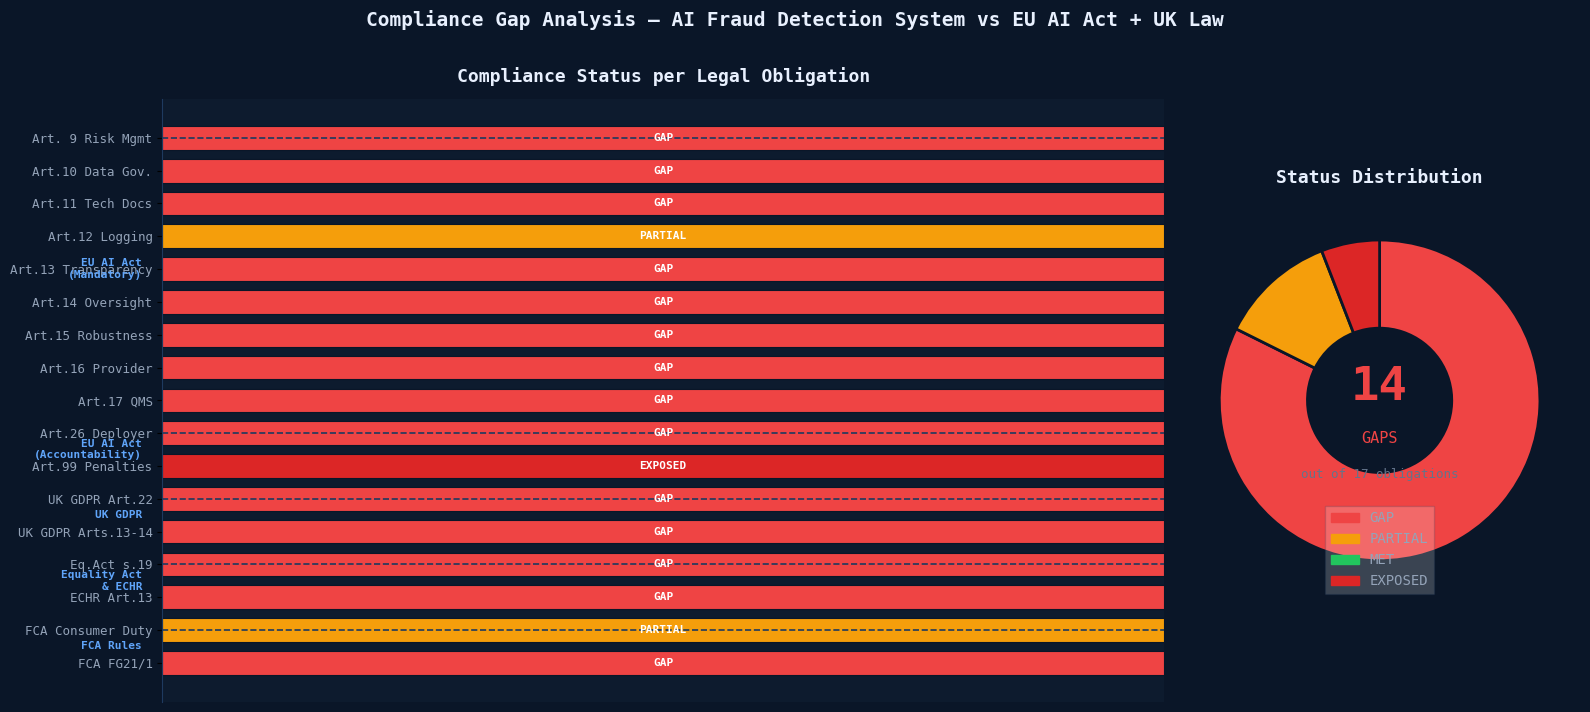


  GAPs: 14  |  PARTIAL: 2  |  MET: 0  |  EXPOSED: 1
  None of the 9 mandatory EU AI Act articles is fully satisfied.


In [9]:

# ══════════════════════════════════════════════════════════════════════════════
#  MODULE B — COMPLIANCE GAP HEATMAP
#
#  PURPOSE: Shows WHICH laws are met, partially met or unmet for this system.
#  Unlike a table, the heatmap lets you see at a glance:
#    • Which legal regime has the most gaps (EU AI Act vs UK law)
#    • How compliance is distributed across article groups
#    • What PARTIAL means versus a full GAP
#
#  READING THE CHART:
#    Red  = GAP — obligation completely unmet
#    Amber = PARTIAL — some steps taken but not complete
#    Blue  = MET — fully compliant (none currently)
# ══════════════════════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Group laws by regime
REGIME_GROUPS = {
    "EU AI Act\n(Mandatory)":  ["A9","A10","A11","A12","A13","A14","A15","A16","A17"],
    "EU AI Act\n(Accountability)": ["A26","A99"],
    "UK GDPR":                 ["G22","G13"],
    "Equality Act\n& ECHR":    ["EQ19","ECHR"],
    "FCA Rules":               ["FCD","FG21"],
}

STATUS_NUM = {"TRIGGER":0,"MET":3,"PARTIAL":2,"GAP":1,"EXPOSED":0.5}
STATUS_COLOR_MAP = {
    "MET":"#22C55E","PARTIAL":"#F59E0B","GAP":"#EF4444",
    "TRIGGER":"#2563EB","EXPOSED":"#DC2626"
}

fig, axes = plt.subplots(1, 2, figsize=(16, 7),
                         gridspec_kw={"width_ratios":[3, 1.2]})
fig.patch.set_facecolor("#0A1628")

# ── LEFT: Per-article status bars ─────────────────────────────────────────────
ax = axes[0]
ax.set_facecolor("#0D1B2E")

all_laws_ordered = []
group_boundaries = []
group_labels_y   = []
cur = 0
for grp, ids in REGIME_GROUPS.items():
    group_boundaries.append(cur - 0.5)
    group_labels_y.append(cur + len(ids)/2 - 0.5)
    for lid in ids:
        all_laws_ordered.append((lid, grp))
    cur += len(ids)
group_boundaries.append(cur - 0.5)

colors_bar, labels_bar, statuses = [], [], []
for lid, grp in all_laws_ordered:
    st = COMPLIANCE.get(lid, "GAP")
    colors_bar.append(STATUS_COLOR_MAP.get(st, "#EF4444"))
    labels_bar.append(LAWS[lid]["label"].replace("\n"," "))
    statuses.append(st)

y_pos = np.arange(len(all_laws_ordered))
bars  = ax.barh(y_pos, [1]*len(y_pos), color=colors_bar,
                height=0.72, edgecolor="#0A1628", linewidth=0.8)

# Status text inside bars
for i, (bar, st) in enumerate(zip(bars, statuses)):
    ax.text(0.5, bar.get_y() + bar.get_height()/2, st,
            ha="center", va="center", fontsize=8,
            fontfamily="monospace", fontweight="bold",
            color="white")

# Law labels on left
ax.set_yticks(y_pos)
ax.set_yticklabels(labels_bar, fontsize=9, fontfamily="monospace", color="#94A3B8")
ax.set_xticks([])
ax.set_xlim(0, 1.0)
ax.invert_yaxis()

# Group dividers and labels
for i, (grp_id, grp_lbl) in enumerate(REGIME_GROUPS.items()):
    y_start = group_boundaries[i]
    y_end   = group_boundaries[i+1]
    ax.axhline(y=y_start + 0.5, color="#1E3A5F", linewidth=1.2, linestyle="--")
    ax.text(-0.02, group_labels_y[i], grp_id,
            ha="right", va="center",
            fontsize=8, fontfamily="monospace",
            color="#60A5FA", fontweight="bold",
            transform=ax.get_yaxis_transform())

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_visible(False)
ax.spines["left"].set_color("#1E3A5F")
ax.set_title("Compliance Status per Legal Obligation",
             color="#E8F0FE", fontsize=13, fontfamily="monospace",
             fontweight="bold", pad=12)

# ── RIGHT: Summary donut ───────────────────────────────────────────────────────
ax2 = axes[1]
ax2.set_facecolor("#0D1B2E")

from collections import Counter
# Exclude trigger
st_counts = Counter(
    st for lid, st in COMPLIANCE.items()
    if st not in ("TRIGGER",)
)
labels_pie = list(st_counts.keys())
sizes_pie  = list(st_counts.values())
colors_pie = [STATUS_COLOR_MAP.get(s, "#EF4444") for s in labels_pie]

wedges, texts = ax2.pie(
    sizes_pie, labels=None,
    colors=colors_pie,
    startangle=90, counterclock=False,
    wedgeprops={"edgecolor":"#0A1628","linewidth":2,"width":0.55}
)

# Centre text
ax2.text(0, 0.08, f"{st_counts.get('GAP',0)}", ha="center", va="center",
         fontsize=34, fontweight="800", color="#EF4444", fontfamily="monospace")
ax2.text(0, -0.24, "GAPS", ha="center", va="center",
         fontsize=11, color="#EF4444", fontfamily="monospace")
ax2.text(0, -0.46, f"out of {sum(sizes_pie)} obligations", ha="center", va="center",
         fontsize=9, color="#64748B", fontfamily="monospace")

ax2.set_title("Status Distribution",
             color="#E8F0FE", fontsize=13, fontfamily="monospace",
             fontweight="bold", pad=12)

# Legend
legend_patches = [
    mpatches.Patch(color=STATUS_COLOR_MAP[s], label=s)
    for s in ["GAP","PARTIAL","MET","EXPOSED"]
]
ax2.legend(handles=legend_patches, loc="lower center",
           fancybox=False, frameon=True,
           framealpha=0.2, edgecolor="#1E3A5F",
           labelcolor="#94A3B8", fontsize=9,
           prop={"family":"monospace"})

fig.suptitle(
    "Compliance Gap Analysis — AI Fraud Detection System vs EU AI Act + UK Law",
    color="#E8F0FE", fontsize=14, fontweight="bold",
    fontfamily="monospace", y=1.01
)
plt.tight_layout()
plt.savefig("module_b_compliance_heatmap.png", dpi=150,
            bbox_inches="tight", facecolor="#0A1628")
plt.show()
print(f"\n  GAPs: {st_counts.get('GAP',0)}  |  PARTIAL: {st_counts.get('PARTIAL',0)}  |  "
      f"MET: {st_counts.get('MET',0)}  |  EXPOSED: {st_counts.get('EXPOSED',0)}")
print("  None of the 9 mandatory EU AI Act articles is fully satisfied.")



---
## Module C — Risk Register — L×I Matrix with Law Traceability

> ISO 31000 Likelihood × Impact scoring. Every risk bubble is linked to the specific laws it violates. Hover for full L and I scoring rationale.


In [10]:

# ══════════════════════════════════════════════════════════════════════════════
#  MODULE C — RISK REGISTER L×I HEATMAP (ISO 31000)
#
#  PURPOSE: Visualises all 10 identified risks on a 5×5 Likelihood × Impact
#  matrix. Each risk node is linked to the specific laws it violates.
#  Hover over each risk bubble for:
#    • The specific risk description
#    • Why THIS Likelihood score was assigned (evidence-based)
#    • Why THIS Impact score was assigned
#    • Which laws it relates to
#
#  ISO 31000 PRINCIPLE: Every score must be justified by evidence, not intuition.
# ══════════════════════════════════════════════════════════════════════════════

SEV_COL_MAP = {
    "Critical": "#DC2626",
    "High":     "#F97316",
    "Medium":   "#F59E0B",
    "Low":      "#22C55E",
}
SEV_SZ = {"Critical":52,"High":42,"Medium":32,"Low":24}

# Background 5×5 matrix
z_bg = [[l*i for i in range(1,6)] for l in range(1,6)]
cscale = [
    [0.0,"#0A1628"],[0.15,"#0A1628"],[0.35,"#1C2D10"],
    [0.55,"#4A2008"],[0.75,"#7C1A1A"],[1.0,"#EF4444"]
]

fig = make_subplots(1, 2,
    column_widths=[0.65, 0.35],
    subplot_titles=["L×I Risk Matrix — ISO 31000", "Risk Severity Breakdown"],
    specs=[[{"type":"heatmap"},{"type":"bar"}]])

# Heatmap background
fig.add_trace(go.Heatmap(
    z=z_bg, x=[1,2,3,4,5], y=[1,2,3,4,5],
    colorscale=cscale, showscale=True, zmin=1, zmax=25, opacity=0.85,
    colorbar=dict(
        title=dict(text="L×I Score", font=dict(color="#94A3B8",size=10,family="monospace")),
        tickfont=dict(color="#94A3B8"),
        bgcolor="rgba(10,22,40,0.8)",
    ),
    hovertemplate="Likelihood=%{y} × Impact=%{x} = %{z}<extra></extra>",
), row=1, col=1)

# Matrix score labels
for l in range(1,6):
    for i in range(1,6):
        fig.add_annotation(x=i, y=l, text=str(l*i),
            font=dict(size=9, color="rgba(255,255,255,0.18)", family="monospace"),
            showarrow=False, row=1, col=1)

# Risk markers
for _, r in RISKS.iterrows():
    laws_str = " · ".join([LAWS[lid]["full"] for lid in r["Laws"] if lid in LAWS])
    fig.add_trace(go.Scatter(
        x=[r["I"]], y=[r["L"]],
        mode="markers+text",
        marker=dict(
            size=SEV_SZ[r["Severity"]],
            color=SEV_COL_MAP[r["Severity"]],
            line=dict(color="#0A1628", width=2),
            opacity=0.92,
        ),
        text=[r["ID"].replace("R-","")],
        textfont=dict(size=9, color="white", family="monospace"),
        textposition="middle center",
        name=r["ID"],
        hovertemplate=(
            f"<b>{r['ID']}</b><br>{r['Risk']}<br><br>"
            f"<b>L={r['L']}:</b> {r['L_why']}<br>"
            f"<b>I={r['I']}:</b> {r['I_why']}<br>"
            f"<b>Score: {r['Score']} — {r['Severity']}</b><br>"
            f"<b>Laws:</b> {laws_str}<extra></extra>"
        ),
    ), row=1, col=1)

# Severity bar chart
sev_order = ["Critical","High","Medium","Low"]
sev_counts = [len(RISKS[RISKS["Severity"]==s]) for s in sev_order]
fig.add_trace(go.Bar(
    x=sev_order, y=sev_counts,
    marker=dict(
        color=[SEV_COL_MAP[s] for s in sev_order],
        line=dict(color="#0A1628", width=2),
    ),
    text=sev_counts,
    textposition="outside",
    textfont=dict(color="white", family="monospace", size=14),
    hovertemplate="%{x}: %{y} risks<extra></extra>",
), row=1, col=2)

fig.update_layout(
    paper_bgcolor="#050B14", plot_bgcolor="#0D1B2E",
    font=dict(color="#E8F0FE", family="monospace"),
    title=dict(
        text="Risk Register — All 10 Risks with ISO 31000 L×I Scoring Rationale",
        font=dict(size=14, color="#E8F0FE"),
    ),
    height=520,
    showlegend=False,
    margin=dict(l=20,r=20,t=60,b=20),
    hoverlabel=dict(bgcolor="#0F2040", bordercolor="#EF4444",
                    font=dict(color="#E8F0FE", size=11)),
    xaxis=dict(title="Impact →", tickvals=[1,2,3,4,5],
               gridcolor="rgba(37,99,235,0.12)", tickfont=dict(color="#94A3B8")),
    yaxis=dict(title="Likelihood →", tickvals=[1,2,3,4,5],
               gridcolor="rgba(37,99,235,0.12)", tickfont=dict(color="#94A3B8")),
    xaxis2=dict(gridcolor="rgba(37,99,235,0.12)", tickfont=dict(color="#94A3B8")),
    yaxis2=dict(gridcolor="rgba(37,99,235,0.12)", tickfont=dict(color="#94A3B8"),
                title="Count"),
)
fig.update_annotations(font=dict(color="#94A3B8", family="monospace", size=10))
fig.show()

critical = RISKS[RISKS["Severity"]=="Critical"]
print(f"\n  Critical risks (Score ≥16): {len(critical)}")
for _, r in critical.iterrows():
    print(f"    {r['ID']}  L={r['L']}×I={r['I']}={r['Score']}  {r['Risk'][:50]}")



  Critical risks (Score ≥16): 3
    R-01  L=4×I=4=16  False positive — legitimate transaction blocked
    R-04  L=4×I=4=16  Automation bias — over-reliance on AI score
    R-08  L=4×I=4=16  Opaque model — Deployer Trap (Art.16 v3)



---
## Module D — Oversight Impossibility — Mathematical Proof

> Proves that EU AI Act Art.14 compliance is legally required but operationally impossible at 50,000 transactions/day. Original portfolio argument. Three proxy solutions compared.


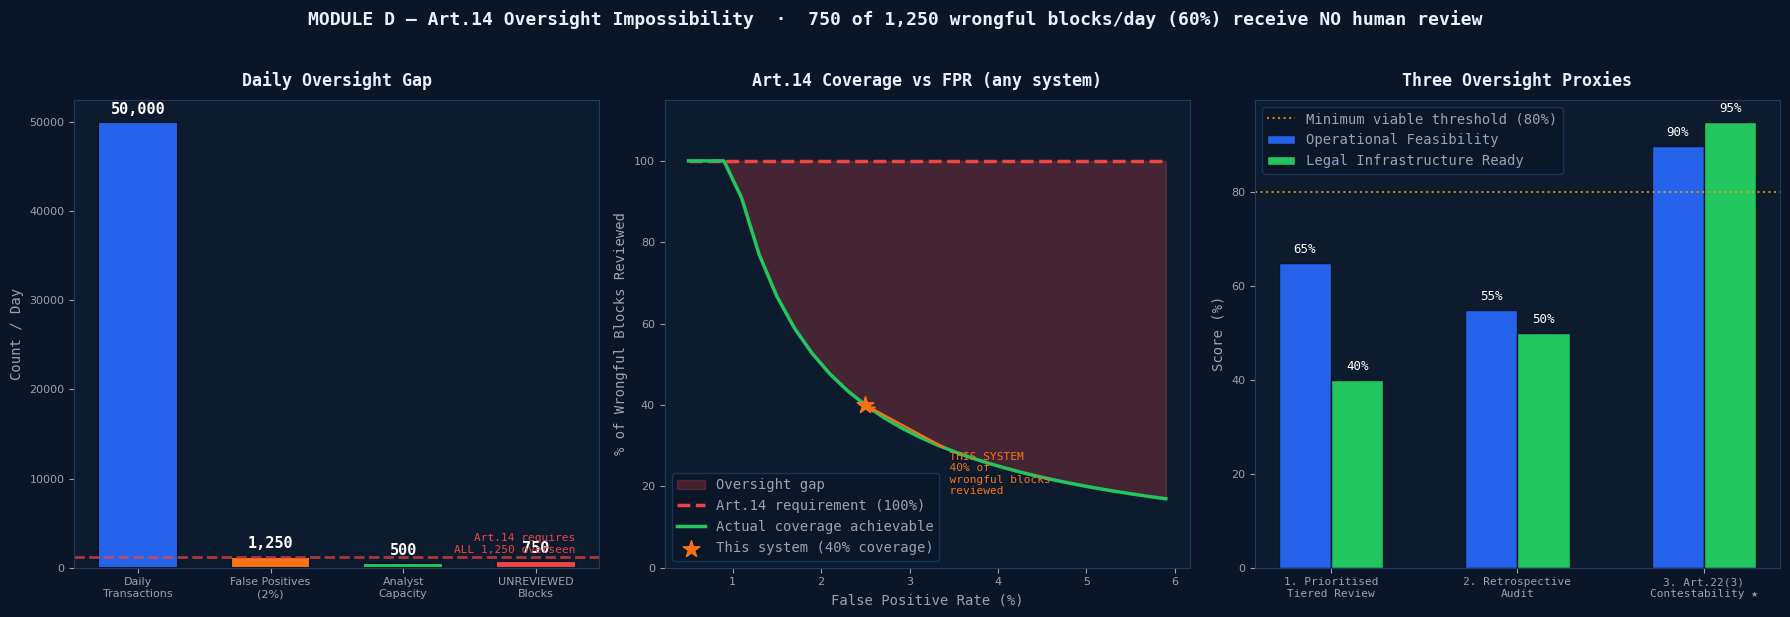


  Art.14 requires: 100% of 1,250 wrongful blocks effectively overseen
  Analyst capacity: 500/day
  Coverage achievable: 40%
  Structural gap: 750 blocks (60%) with NO review — Art.14 breach by design
  Conclusion: Only Art.22(3) contestability has existing legal infrastructure


In [11]:

# ══════════════════════════════════════════════════════════════════════════════
#  MODULE D — OVERSIGHT IMPOSSIBILITY — MATHEMATICAL VISUALISATION
#
#  PURPOSE: Proves mathematically that EU AI Act Art.14 compliance is legally
#  required but operationally impossible at the current system scale.
#
#  ORIGINAL ARGUMENT: Art.14(1) requires the system to be "effectively
#  overseen by natural persons." Art.14(4)(e) prohibits overwhelming analysts.
#  At 50,000 transactions/day with 2.5% FPR and 500 analyst capacity:
#    → 1,250 wrongful blocks/day
#    → 60% receive no human review
#    → Art.14 compliance is a legal fiction
#
#  This is the core original argument of the portfolio.
# ══════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.patch.set_facecolor("#0A1628")

# ── CHART 1: Daily flow waterfall ──────────────────────────────────────────────
ax1 = axes[0]
ax1.set_facecolor("#0D1B2E")

labels = ["Daily\nTransactions", f"False Positives\n({int(SYSTEM['fpr']*100)}%)",
          "Analyst\nCapacity", "UNREVIEWED\nBlocks"]
values = [SYSTEM["daily_txn"], FPD, SYSTEM["analyst_capacity"], UNREVIEWED]
bar_colors = [PALETTE["blue"], PALETTE["orange"], PALETTE["green"], PALETTE["red"]]

bars = ax1.bar(labels, values, color=bar_colors,
               edgecolor="#0A1628", linewidth=1.5, width=0.6)

for bar, val in zip(bars, values):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 600,
             f"{val:,}",
             ha="center", va="bottom", fontsize=11,
             fontfamily="monospace", fontweight="bold",
             color="white")

# Art.14 requirement line
ax1.axhline(y=FPD, color=PALETTE["red"], linewidth=2, linestyle="--", alpha=0.7)
ax1.text(3.3, FPD + 400,
         f"Art.14 requires\nALL {FPD:,} overseen",
         fontsize=8, color=PALETTE["red"], fontfamily="monospace",
         ha="right")

ax1.set_ylabel("Count / Day", color="#94A3B8", fontfamily="monospace")
ax1.tick_params(colors="#94A3B8", labelsize=8)
ax1.set_facecolor("#0D1B2E")
for sp in ax1.spines.values(): sp.set_color("#1E3A5F")
ax1.yaxis.label.set_fontfamily("monospace")
ax1.set_title("Daily Oversight Gap", color="#E8F0FE",
              fontfamily="monospace", fontweight="bold", pad=10)

# ── CHART 2: Coverage across FPR scenarios ─────────────────────────────────────
ax2 = axes[1]
ax2.set_facecolor("#0D1B2E")

fpr_range = np.arange(0.005, 0.06, 0.002)
fp_counts = SYSTEM["daily_txn"] * fpr_range
coverage  = np.minimum(100, SYSTEM["analyst_capacity"] / fp_counts * 100)
required  = np.full_like(fpr_range, 100.0)
gap_area  = required - coverage

ax2.fill_between(fpr_range*100, coverage, required,
                 alpha=0.25, color=PALETTE["red"], label="Oversight gap")
ax2.plot(fpr_range*100, required,
         color=PALETTE["red"], linewidth=2.5, linestyle="--",
         label="Art.14 requirement (100%)")
ax2.plot(fpr_range*100, coverage,
         color=PALETTE["green"], linewidth=2.5,
         label="Actual coverage achievable")

# Mark this system
this_cov = min(100, SYSTEM["analyst_capacity"] / FPD * 100)
ax2.scatter([SYSTEM["fpr"]*100], [this_cov],
            s=160, color=PALETTE["orange"], zorder=5,
            marker="*", label=f"This system ({this_cov:.0f}% coverage)")
ax2.annotate(f"  THIS SYSTEM\n  {this_cov:.0f}% of\n  wrongful blocks\n  reviewed",
             xy=(SYSTEM["fpr"]*100, this_cov),
             xytext=(SYSTEM["fpr"]*100 + 0.8, this_cov - 22),
             fontsize=8, color=PALETTE["orange"], fontfamily="monospace",
             arrowprops=dict(arrowstyle="->", color=PALETTE["orange"], lw=1.5))

ax2.set_xlabel("False Positive Rate (%)", color="#94A3B8", fontfamily="monospace")
ax2.set_ylabel("% of Wrongful Blocks Reviewed", color="#94A3B8", fontfamily="monospace")
ax2.set_ylim(0, 115)
ax2.tick_params(colors="#94A3B8", labelsize=8)
for sp in ax2.spines.values(): sp.set_color("#1E3A5F")
ax2.set_facecolor("#0D1B2E")
ax2.legend(fontsize=8, facecolor="#0A1628", edgecolor="#1E3A5F",
           labelcolor="#94A3B8", prop={"family":"monospace"})
ax2.set_title("Art.14 Coverage vs FPR (any system)", color="#E8F0FE",
              fontfamily="monospace", fontweight="bold", pad=10)
ax2.yaxis.label.set_fontfamily("monospace")
ax2.xaxis.label.set_fontfamily("monospace")

# ── CHART 3: Three proxies comparison ──────────────────────────────────────────
ax3 = axes[2]
ax3.set_facecolor("#0D1B2E")

proxies = ["1. Prioritised\nTiered Review", "2. Retrospective\nAudit", "3. Art.22(3)\nContestability ★"]
feasibility = [65, 55, 90]
legality    = [40, 50, 95]
bar_w = 0.28
x = np.arange(len(proxies))

b1 = ax3.bar(x - bar_w/2, feasibility, bar_w,
             color=PALETTE["blue"], label="Operational Feasibility",
             edgecolor="#0A1628", linewidth=1)
b2 = ax3.bar(x + bar_w/2, legality, bar_w,
             color=PALETTE["green"], label="Legal Infrastructure Ready",
             edgecolor="#0A1628", linewidth=1)

for bars_group in [b1, b2]:
    for bar in bars_group:
        ax3.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 1.5,
                 f"{int(bar.get_height())}%",
                 ha="center", va="bottom", fontsize=9,
                 fontfamily="monospace", color="white")

ax3.axhline(80, color=PALETTE["amber"], linewidth=1.5, linestyle=":",
            alpha=0.8, label="Minimum viable threshold (80%)")
ax3.set_xticks(x)
ax3.set_xticklabels(proxies, color="#94A3B8", fontsize=8,
                    fontfamily="monospace")
ax3.set_ylabel("Score (%)", color="#94A3B8", fontfamily="monospace")
ax3.tick_params(colors="#94A3B8", labelsize=8)
for sp in ax3.spines.values(): sp.set_color("#1E3A5F")
ax3.set_facecolor("#0D1B2E")
ax3.legend(fontsize=8, facecolor="#0A1628", edgecolor="#1E3A5F",
           labelcolor="#94A3B8", prop={"family":"monospace"})
ax3.set_title("Three Oversight Proxies", color="#E8F0FE",
              fontfamily="monospace", fontweight="bold", pad=10)
ax3.yaxis.label.set_fontfamily("monospace")

fig.suptitle(
    f"MODULE D — Art.14 Oversight Impossibility  ·  "
    f"{UNREVIEWED:,} of {FPD:,} wrongful blocks/day ({PCT_UNREV}%) receive NO human review",
    color="#E8F0FE", fontsize=13, fontfamily="monospace", fontweight="bold", y=1.02
)
plt.tight_layout()
plt.savefig("module_d_oversight_impossibility.png", dpi=150,
            bbox_inches="tight", facecolor="#0A1628")
plt.show()
print(f"\n  Art.14 requires: 100% of {FPD:,} wrongful blocks effectively overseen")
print(f"  Analyst capacity: {SYSTEM['analyst_capacity']:,}/day")
print(f"  Coverage achievable: {min(100,round(SYSTEM['analyst_capacity']/FPD*100))}%")
print(f"  Structural gap: {UNREVIEWED:,} blocks ({PCT_UNREV}%) with NO review — Art.14 breach by design")
print(f"  Conclusion: Only Art.22(3) contestability has existing legal infrastructure")



---
## Module E — Enforcement Cases Timeline

> Five real enforcement cases mapped to the EU AI Act articles they mirror and the risks in this system's register they directly analogise. The EU AI Act codifies lessons from all five.


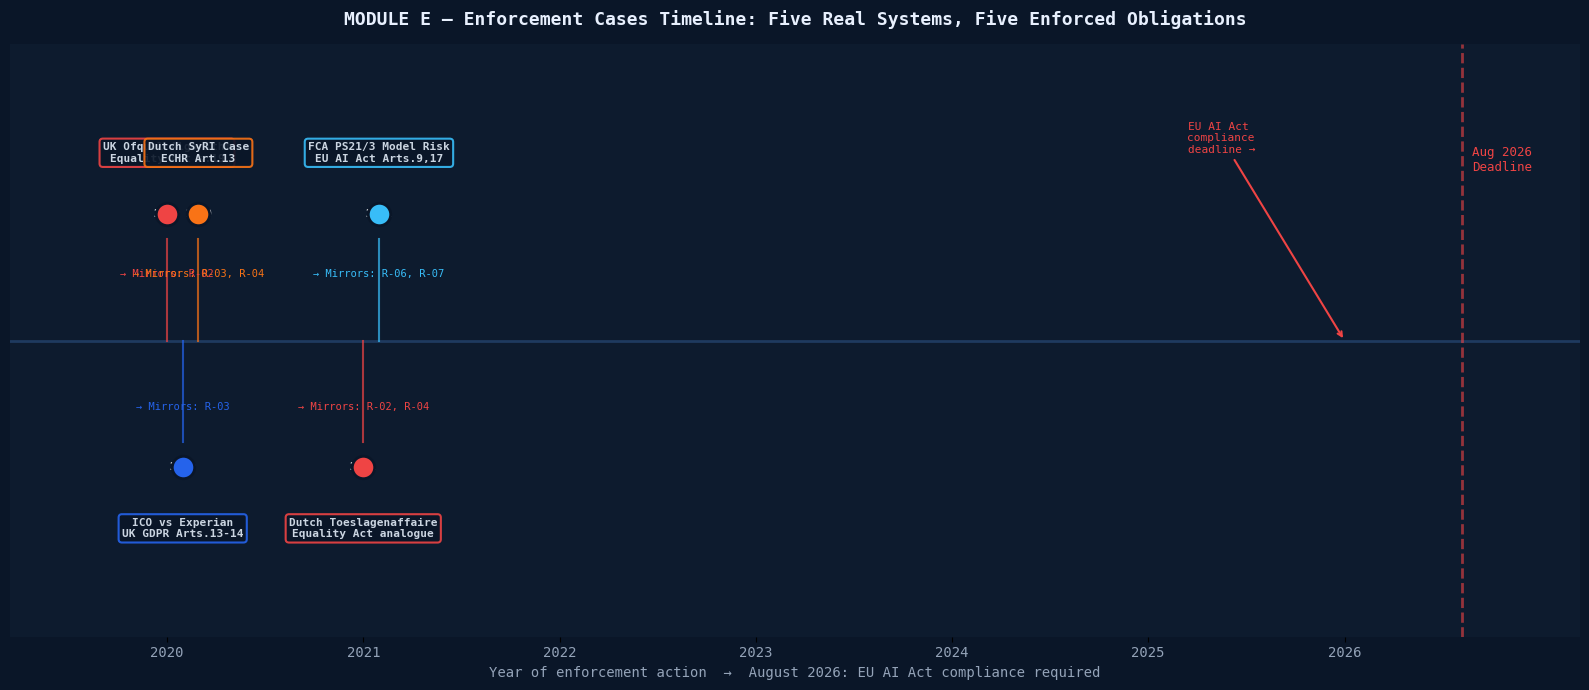


  ENFORCEMENT CASE DETAIL TABLE
  Case                                Law                    Mirrors Articles          Mirrors Risks
  --------------------------------------------------------------------------------------------------------------
  UK Ofqual Algorithm                 Equality Act s.19      A10, EQ19                 R-02
  ICO vs Experian                     UK GDPR Arts.13-14     A13, G13                  R-03
  Dutch SyRI Case                     ECHR Art.13            A14, A13, ECHR            R-03, R-04
  Dutch Toeslagenaffaire              Equality Act analogue  A10, EQ19, A14            R-02, R-04
  FCA PS21/3 Model Risk               EU AI Act Arts.9,17    A9, A17                   R-06, R-07

  Synthesis: Each case mirrors a specific gap in this system.
  The EU AI Act codifies lessons from all five — these are not theoretical risks.


In [13]:

# ══════════════════════════════════════════════════════════════════════════════
#  MODULE E — ENFORCEMENT CASES TIMELINE
#
#  PURPOSE: Shows that these legal risks are not theoretical — courts and
#  regulators have already acted against comparable AI systems.
#
#  RELATIONAL ELEMENT: Each case is mapped to:
#    1. The law it enforced
#    2. The EU AI Act articles that case most closely mirrors
#    3. The risks in this system's register that it directly analogises
#
#  KEY ARGUMENT: The EU AI Act codifies lessons from these cases.
#  If the fraud detection system were scrutinised today, it would face
#  the same enforcement outcome.
# ══════════════════════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(16, 7))
fig.patch.set_facecolor("#0A1628")
ax.set_facecolor("#0D1B2E")

SEV_CASE_COL = {
    "Equality Act s.19":    PALETTE["red"],
    "UK GDPR Arts.13-14":   PALETTE["blue"],
    "ECHR Art.13":          PALETTE["orange"],
    "Equality Act analogue":PALETTE["red"],
    "EU AI Act Arts.9,17":  PALETTE["sky"],
}
y_pos = [0.35, -0.35, 0.35, -0.35, 0.35]  # alternate above/below

# Timeline baseline
ax.axhline(0, color="#1E3A5F", linewidth=2, zorder=1)
ax.axvline(2026.6, color=PALETTE["red"], linewidth=2, linestyle="--", alpha=0.6)
ax.text(2026.65, 0.5, "Aug 2026\nDeadline", fontsize=9,
        color=PALETTE["red"], fontfamily="monospace", va="center")

# 2026 compliance deadline marker
ax.annotate("EU AI Act\ncompliance\ndeadline →",
            xy=(2026, 0), xytext=(2025.2, 0.52),
            fontsize=8, color=PALETTE["red"], fontfamily="monospace",
            arrowprops=dict(arrowstyle="->", color=PALETTE["red"], lw=1.5))

for i, (case, y) in enumerate(zip(CASES, y_pos)):
    col = SEV_CASE_COL.get(case["Law"], PALETTE["amber"])
    yr  = case["Year"] + (i % 3) * 0.08  # slight x jitter

    # Vertical line
    ax.plot([yr, yr], [0, y * 0.8], color=col, linewidth=1.5,
            linestyle="-", alpha=0.7, zorder=2)

    # Circle node
    ax.scatter(yr, y, s=260, color=col, zorder=5,
               edgecolors="#0A1628", linewidths=2)
    ax.text(yr, y, str(case["Year"]), ha="center", va="center",
            fontsize=8, color="white", fontfamily="monospace", fontweight="bold")

    # Label card
    label_y = y + (0.14 if y > 0 else -0.14)
    bbox_props = dict(boxstyle="round,pad=0.3", facecolor="#0A1628",
                      edgecolor=col, linewidth=1.5, alpha=0.9)

    ax.text(yr, label_y, f"{case['Case']}\n{case['Law']}",
            ha="center", va="bottom" if y > 0 else "top",
            fontsize=8, color="#CBD5E1", fontfamily="monospace",
            fontweight="bold", bbox=bbox_props)

    # Risk links below timeline
    risk_txt = "→ Mirrors: " + ", ".join(case["Mirrors_risks"])
    ax.text(yr, y - (0.18 if y > 0 else -0.18),
            risk_txt, ha="center",
            va="bottom" if y > 0 else "top",
            fontsize=7.5, color=col, fontfamily="monospace")

ax.set_xlim(2019.2, 2027.2)
ax.set_ylim(-0.82, 0.82)
ax.set_xticks(range(2020, 2027))
ax.set_xticklabels([str(y) for y in range(2020,2027)],
                   color="#94A3B8", fontfamily="monospace")
ax.set_yticks([])
for sp in ax.spines.values(): sp.set_visible(False)

# Lesson summary boxes at bottom
lesson_y = -0.72
for i, case in enumerate(CASES):
    col = SEV_CASE_COL.get(case["Law"], PALETTE["amber"])
    ax.text(2019.5, lesson_y + i * (-0.001),  # hidden — shown in legend
            "", fontsize=7)

# Bottom key
ax.set_xlabel("Year of enforcement action  →  August 2026: EU AI Act compliance required",
              color="#94A3B8", fontfamily="monospace")

ax.set_title(
    "MODULE E — Enforcement Cases Timeline: Five Real Systems, Five Enforced Obligations",
    color="#E8F0FE", fontsize=13, fontfamily="monospace", fontweight="bold", pad=14
)

plt.tight_layout()
plt.savefig("module_e_enforcement_timeline.png", dpi=150,
            bbox_inches="tight", facecolor="#0A1628")
plt.show()

# Print case detail table
print("\n  ENFORCEMENT CASE DETAIL TABLE")
print(f"  {'Case':<35} {'Law':<22} {'Mirrors Articles':<25} {'Mirrors Risks'}")
print("  " + "-"*110)
for c in CASES:
    arts = ", ".join(c["Mirrors_articles"])
    risks = ", ".join(c["Mirrors_risks"])
    print(f"  {c['Case']:<35} {c['Law']:<22} {arts:<25} {risks}")
print("\n  Synthesis: Each case mirrors a specific gap in this system.")
print("  The EU AI Act codifies lessons from all five — these are not theoretical risks.")



---
## Module F — Governance Action → Law → Risk Dashboard

> Shows how each P1/P2/P3 action directly satisfies specific legal obligations and mitigates specific risks. Answers 'what do we do now?' with legal justification for every action.


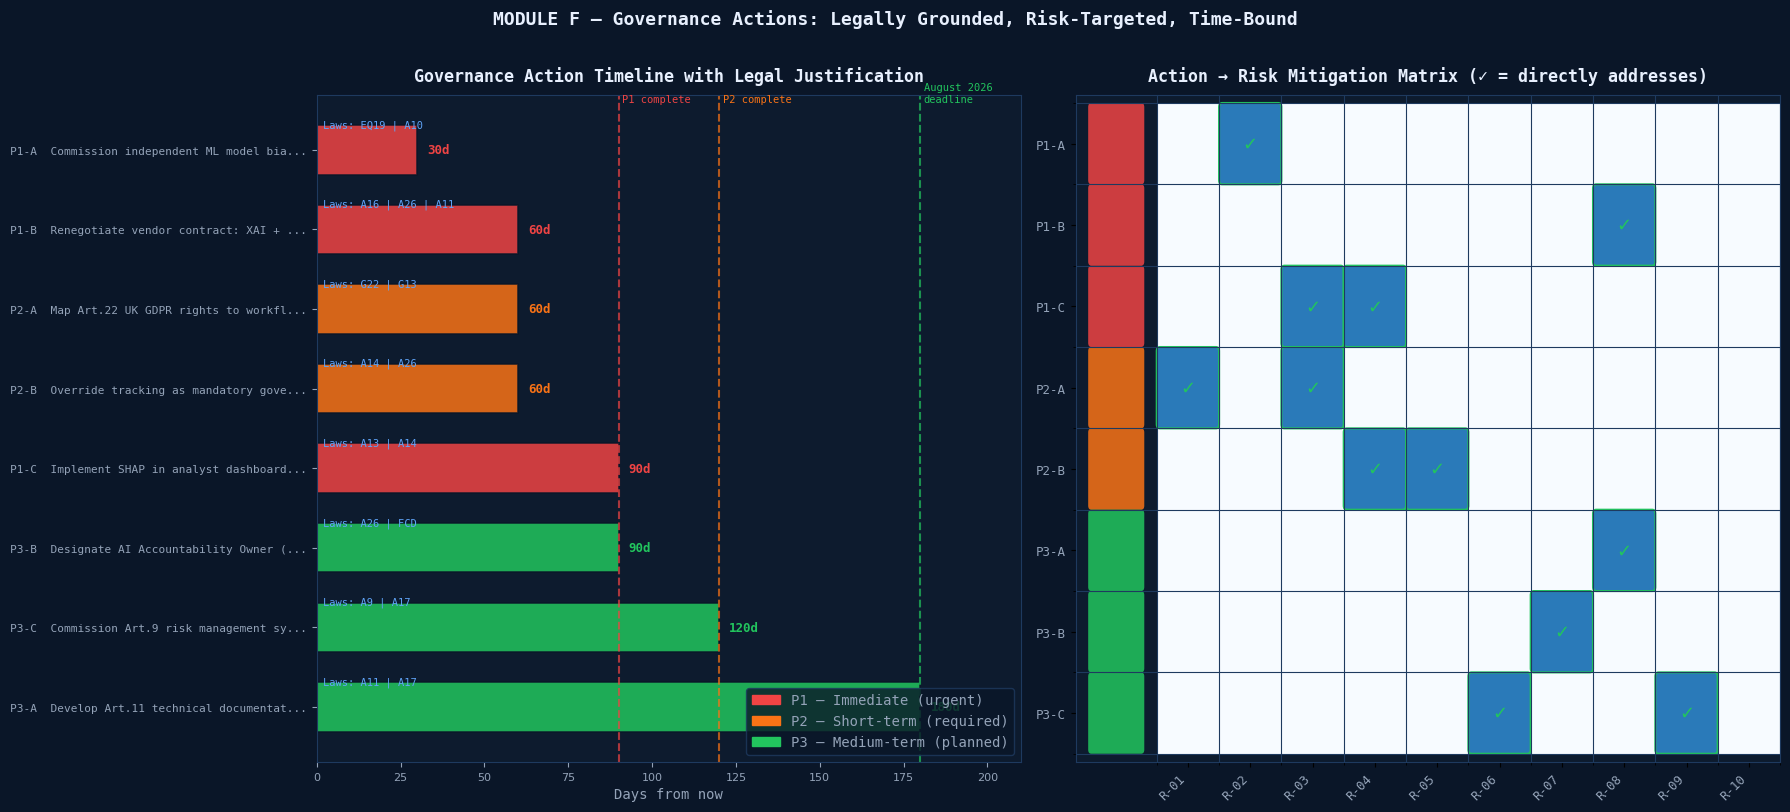


  GOVERNANCE ACTION SUMMARY
  Code     Priority Days   Laws Addressed               Risks Mitigated
  --------------------------------------------------------------------------------
  P1-A     P1     30     EQ19, A10                    R-02
  P1-B     P1     60     A16, A26, A11                R-08
  P1-C     P1     90     A13, A14                     R-03, R-04
  P2-A     P2     60     G22, G13                     R-01, R-03
  P2-B     P2     60     A14, A26                     R-04, R-05
  P3-A     P3     180    A11, A17                     R-08
  P3-B     P3     90     A26, FCD                     R-07
  P3-C     P3     120    A9, A17                      R-06, R-09


In [16]:

# ══════════════════════════════════════════════════════════════════════════════
#  MODULE F — GOVERNANCE ACTION → LAW → RISK RELATIONAL DASHBOARD
#
#  PURPOSE: Shows how each governance action (P1/P2/P3) directly addresses
#  specific legal obligations and specific risks. This is the "so what?" slide:
#  it answers "what do we do now?" — with legal justification for each action.
#
#  RELATIONAL ELEMENT:
#    Action → which Laws it satisfies → which Risks it mitigates
#    This demonstrates that governance actions are legally grounded, not arbitrary.
# ══════════════════════════════════════════════════════════════════════════════

P_COL = {"P1": PALETTE["red"], "P2": PALETTE["orange"], "P3": PALETTE["green"]}

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.patch.set_facecolor("#0A1628")

# ── LEFT: Gantt-style action timeline ─────────────────────────────────────────
ax1 = axes[0]
ax1.set_facecolor("#0D1B2E")

sorted_actions = sorted(ACTIONS, key=lambda a: a["Days"])
y_labels = [f"{a['Code']}  {a['Action'][:35]}..."
            if len(a["Action"]) > 35 else f"{a['Code']}  {a['Action']}"
            for a in sorted_actions]

for i, action in enumerate(sorted_actions):
    col = P_COL[action["Priority"]]
    bar_w = max(action["Days"] / 2, 8)

    ax1.barh(i, action["Days"], left=0,
             color=col, height=0.62,
             edgecolor="#0A1628", linewidth=1.2, alpha=0.85)
    ax1.text(action["Days"] + 3, i,
             f"{action['Days']}d",
             va="center", fontsize=9,
             color=col, fontfamily="monospace", fontweight="bold")

    # Laws addressed (small badges)
    law_str = " | ".join(action["Laws"][:3])
    ax1.text(2, i - 0.32, f"Laws: {law_str}",
             va="center", fontsize=7.5,
             color="#60A5FA", fontfamily="monospace")

ax1.set_yticks(range(len(sorted_actions)))
ax1.set_yticklabels(y_labels, fontsize=8.5, fontfamily="monospace", color="#94A3B8")
ax1.set_xlabel("Days from now", color="#94A3B8", fontfamily="monospace")
ax1.set_xlim(0, 210)
ax1.invert_yaxis()

# Deadline markers
for d, lbl, col in [(90,"P1 complete",PALETTE["red"]),
                    (120,"P2 complete",PALETTE["orange"]),
                    (180,"August 2026\ndeadline",PALETTE["green"])]:
    ax1.axvline(d, color=col, linewidth=1.5, linestyle="--", alpha=0.7)
    ax1.text(d+1, -0.6, lbl, fontsize=7.5, color=col, fontfamily="monospace")

for sp in ax1.spines.values(): sp.set_color("#1E3A5F")
ax1.tick_params(colors="#94A3B8", labelsize=8)
ax1.xaxis.label.set_fontfamily("monospace")
ax1.set_title("Governance Action Timeline with Legal Justification",
              color="#E8F0FE", fontfamily="monospace", fontweight="bold", pad=10)

legend_patches = [
    mpatches.Patch(color=P_COL["P1"], label="P1 — Immediate (urgent)"),
    mpatches.Patch(color=P_COL["P2"], label="P2 — Short-term (required)"),
    mpatches.Patch(color=P_COL["P3"], label="P3 — Medium-term (planned)"),
]
ax1.legend(handles=legend_patches, fontsize=8.5,
           facecolor="#0A1628", edgecolor="#1E3A5F",
           labelcolor="#94A3B8", prop={"family":"monospace"},
           loc="lower right")

# ── RIGHT: Action × Risk mitigation matrix ────────────────────────────────────
ax2 = axes[1]
ax2.set_facecolor("#0D1B2E")

action_codes = [a["Code"] for a in ACTIONS]
risk_ids     = list(RISKS["ID"])

# Build matrix: 1 if action mitigates risk
matrix = np.zeros((len(ACTIONS), len(risk_ids)))
for i, action in enumerate(ACTIONS):
    for j, rid in enumerate(risk_ids):
        if rid in action["Risks"]:
            matrix[i, j] = 1

im = ax2.imshow(matrix, cmap="Blues", aspect="auto",
                vmin=0, vmax=1.4, interpolation="nearest")

# Grid lines
ax2.set_xticks(np.arange(-0.5, len(risk_ids), 1), minor=True)
ax2.set_yticks(np.arange(-0.5, len(ACTIONS), 1), minor=True)
ax2.grid(which="minor", color="#1E3A5F", linewidth=0.8)

# Marks
for i in range(len(ACTIONS)):
    for j in range(len(risk_ids)):
        if matrix[i, j] == 1:
            ax2.text(j, i, "✓", ha="center", va="center",
                     fontsize=13, color=PALETTE["green"], fontweight="bold")
            # also highlight the cell
            rect = mpatches.FancyBboxPatch(
                (j - 0.45, i - 0.45), 0.9, 0.9,
                boxstyle="round,pad=0.05",
                linewidth=1.5, edgecolor=PALETTE["green"],
                facecolor="none"
            )
            ax2.add_patch(rect)

ax2.set_xticks(range(len(risk_ids)))
ax2.set_xticklabels(risk_ids, fontsize=9, fontfamily="monospace",
                    color="#94A3B8", rotation=45, ha="right")
ax2.set_yticks(range(len(ACTIONS)))
ax2.set_yticklabels(action_codes, fontsize=9,
                    fontfamily="monospace", color="#94A3B8")

# Priority colour stripes on left
for i, action in enumerate(ACTIONS):
    ax2.add_patch(mpatches.FancyBboxPatch(
        (-1.55, i - 0.45), 0.8, 0.9,
        boxstyle="round,pad=0.05",
        facecolor=P_COL[action["Priority"]],
        edgecolor="none", alpha=0.85
    ))

ax2.set_xlim(-1.8, len(risk_ids) - 0.5)
ax2.set_ylim(-0.6, len(ACTIONS) - 0.4)
ax2.invert_yaxis()
for sp in ax2.spines.values(): sp.set_color("#1E3A5F")
ax2.set_title("Action → Risk Mitigation Matrix (✓ = directly addresses)",
              color="#E8F0FE", fontfamily="monospace", fontweight="bold", pad=10)

fig.suptitle(
    "MODULE F — Governance Actions: Legally Grounded, Risk-Targeted, Time-Bound",
    color="#E8F0FE", fontsize=13, fontfamily="monospace", fontweight="bold", y=1.01
)
plt.tight_layout()
plt.savefig("module_f_governance_dashboard.png", dpi=150,
            bbox_inches="tight", facecolor="#0A1628")
plt.show()

print("\n  GOVERNANCE ACTION SUMMARY")
print(f"  {'Code':<8} {'Priority':<6} {'Days':<6} {'Laws Addressed':<28} {'Risks Mitigated'}")
print("  " + "-"*80)
for a in ACTIONS:
    print(f"  {a['Code']:<8} {a['Priority']:<6} {a['Days']:<6} "
          f"{', '.join(a['Laws']):<28} {', '.join(a['Risks'])}")


---
## Executive Summary

> Combined KPIs from all 6 modules — board-level reporting format.

In [17]:

# ══════════════════════════════════════════════════════════════════════════════
#  EXECUTIVE SUMMARY — Key metrics from all 6 modules
# ══════════════════════════════════════════════════════════════════════════════

from collections import Counter

gaps    = sum(1 for s in COMPLIANCE.values() if s == "GAP")
partial = sum(1 for s in COMPLIANCE.values() if s == "PARTIAL")
met     = sum(1 for s in COMPLIANCE.values() if s == "MET")
critical= len(RISKS[RISKS["Severity"]=="Critical"])
high    = len(RISKS[RISKS["Severity"]=="High"])

kpis = [
    ("EU AI Act Classification",  "HIGH RISK",          PALETTE["red"],    "Annex III §5(b)"),
    ("Compliance Gaps (Arts.9-17)","9 / 9 Articles",    PALETTE["red"],    "All mandatory articles unmet"),
    ("Critical Risks (Score ≥16)", f"{critical} risks", PALETTE["red"],    "R-01, R-04, R-08 — all score 16"),
    ("Daily Wrongful Blocks",      f"{FPD:,}",          PALETTE["orange"], f"{int(SYSTEM['fpr']*100)}% × {SYSTEM['daily_txn']:,} transactions"),
    ("Blocks with NO Review",      f"{PCT_UNREV}%",     PALETTE["orange"], f"{UNREVIEWED:,} of {FPD:,} daily wrongful blocks"),
    ("Compliance Deadline",        "August 2026",       PALETTE["amber"],  "EU AI Act Art.99: €15M or 3% turnover"),
    ("P1 Actions Required",        "3 urgent",          PALETTE["green"],  "Within 30–90 days"),
    ("Governance Actions Total",   f"{len(ACTIONS)}",   PALETTE["blue"],   "P1×3, P2×2, P3×3"),
]

display(HTML(
    '<div style="background:linear-gradient(135deg,#050B14,#0F2040);' +
    'border:1px solid rgba(37,99,235,0.3);border-radius:14px;padding:26px;' +
    'font-family:monospace">' +
    f'<div style="color:#60A5FA;letter-spacing:3px;font-size:10px;' +
    'text-transform:uppercase;margin-bottom:14px">' +
    f'Executive Summary · {datetime.now().strftime("%d %B %Y %H:%M")}</div>' +
    '<div style="display:grid;grid-template-columns:repeat(auto-fit,minmax(200px,1fr));gap:10px;margin-bottom:20px">' +
    "".join([
        f'<div style="background:rgba(255,255,255,0.04);border:1px solid rgba(255,255,255,0.08);' +
        f'border-left:3px solid {col};border-radius:8px;padding:12px">' +
        f'<div style="font-size:20px;font-weight:800;color:{col};letter-spacing:-0.5px">{val}</div>' +
        f'<div style="color:#E8F0FE;font-size:10.5px;font-weight:600;margin-top:4px">{lbl}</div>' +
        f'<div style="color:#475569;font-size:9px;margin-top:3px">{sub}</div></div>'
        for lbl,val,col,sub in kpis
    ]) +
    '</div>' +
    '<div style="color:#475569;font-size:9px;border-top:1px solid rgba(37,99,235,0.15);' +
    'padding-top:12px;margin-top:4px">' +
    '7CS525 Human &amp; Legal Aspects of Cyber Security · University of Derby · 2025/26 · ' +
    'github.com/akingbolastanley1998-byte/fraud-ai-compliance</div></div>'
))

print("\n" + "="*65)
print("  ALL 6 MODULES COMPLETE — AI FRAUD DETECTION COMPLIANCE MAPPER")
print("="*65)
print(f"  EU AI Act compliance:     {met}/{len(LAWS)-1} obligations met (excl. trigger)")
print(f"  Critical risks:           {critical}")
print(f"  Oversight coverage:       {min(100,round(SYSTEM['analyst_capacity']/FPD*100))}%")
print(f"  Enforcement cases mapped: {len(CASES)}")
print(f"  Governance actions:       {len(ACTIONS)}")
print()
print("  This notebook operationalises EU AI Act Art.9 risk management")
print("  and embodies the UK AI White Paper contestability principle:")
print("  the analysis is transparent, reproducible and challengeable.")
print("="*65)



  ALL 6 MODULES COMPLETE — AI FRAUD DETECTION COMPLIANCE MAPPER
  EU AI Act compliance:     0/17 obligations met (excl. trigger)
  Critical risks:           3
  Oversight coverage:       40%
  Enforcement cases mapped: 5
  Governance actions:       8

  This notebook operationalises EU AI Act Art.9 risk management
  and embodies the UK AI White Paper contestability principle:
  the analysis is transparent, reproducible and challengeable.
